In [12]:
import pandas as pd
import numpy as np

np.random.seed(7)
days = 365

environmental_data = {
    'aqi': np.random.randint(10, 180, days), # Air Quality Index
    'temperature_f': np.random.randint(30, 95, days),
    'humidity_pct': np.random.randint(20, 90, days)
}

df_health = pd.DataFrame(environmental_data)

# Admissions rise when AQI is high (poor air) and temperatures are freezing
df_health['hospital_admissions'] = (
    (df_health['aqi'] * 0.15) +
    ((100 - df_health['temperature_f']) * 0.1) +
    np.random.normal(5, 3, days)
).astype(int)

# Cap lower limit at zero admissions
df_health['hospital_admissions'] = df_health['hospital_admissions'].clip(lower=0)
print(df_health.head())

   aqi  temperature_f  humidity_pct  hospital_admissions
0   35             93            61                   15
1   77             34            77                   22
2  161             37            30                   32
3  113             88            53                   19
4  102             32            68                   27


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

X_env = df_health[['aqi', 'temperature_f', 'humidity_pct']]
y_env = df_health['hospital_admissions']

X_tr, X_te, y_tr, y_te = train_test_split(X_env, y_env, test_size=0.2, random_state=7)

regressor = LinearRegression()
regressor.fit(X_tr, y_tr)

predictions = regressor.predict(X_te)
print(f"Model R² R2 Score (Accuracy Metric): {r2_score(y_te, predictions):.3f}")
print(f"Average Prediction Error: {np.sqrt(mean_squared_error(y_te, predictions)):.3f} admissions")

Model R² R2 Score (Accuracy Metric): 0.849
Average Prediction Error: 3.073 admissions


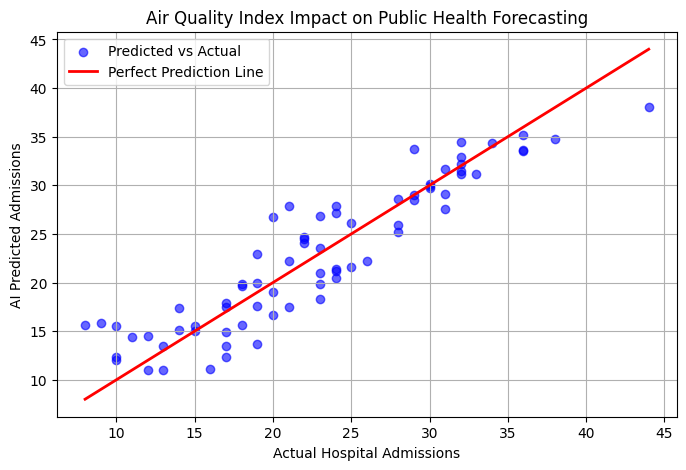

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_te, predictions, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], color='red', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Hospital Admissions')
plt.ylabel('AI Predicted Admissions')
plt.title('Air Quality Index Impact on Public Health Forecasting')
plt.legend()
plt.grid(True)
plt.savefig('pollution_model_accuracy.png') # Saves plot to upload to GitHub
plt.show()